# Coupled Oscillator Normal Modes

This notebook builds a finite mass-spring chain. The small-oscillation equation is

$$\ddot{x}=-Kx,$$

where `K` is the stiffness matrix. The normal-mode frequencies are square roots of the stiffness eigenvalues. A low-frequency polynomial filter isolates the slow collective modes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_masses = 10
spring = 1.0
pinning = 0.3

K = np.zeros((n_masses, n_masses))
for i in range(n_masses):
    if i > 0:
        K[i, i] += spring
        K[i, i - 1] -= spring
    if i < n_masses - 1:
        K[i, i] += spring
        K[i, i + 1] -= spring
K[0, 0] += pinning
K[-1, -1] += pinning

stiffness_eigenvalues, modes = eigh_hermitian(K)
frequencies = np.sqrt(stiffness_eigenvalues)

frequencies[:5]

array([0.2072, 0.4426, 0.7012, 0.9629, 1.2121])

## Low-frequency filtering

Map the lowest stiffness eigenvalue to `+1` and the highest to `-1`, then apply an exponential-like bounded polynomial to emphasize the slowest normal mode.


In [3]:
center = 0.5 * (stiffness_eigenvalues[0] + stiffness_eigenvalues[-1])
half_width = 0.5 * (stiffness_eigenvalues[-1] - stiffness_eigenvalues[0])
A = (center * np.eye(n_masses) - K) / half_width

coeffs = exponential_approximation_polynomial(degree=16, beta=6.0)
initial_displacement = np.zeros(n_masses)
initial_displacement[n_masses // 2] = 1.0

filtered = apply_polynomial_to_hermitian(A, coeffs) @ initial_displacement
filtered = filtered / np.linalg.norm(filtered)
slow_mode = modes[:, 0]
slow_mode_overlap = np.abs(np.vdot(slow_mode, filtered)) ** 2

slow_mode_overlap

np.float64(0.9147264843650682)

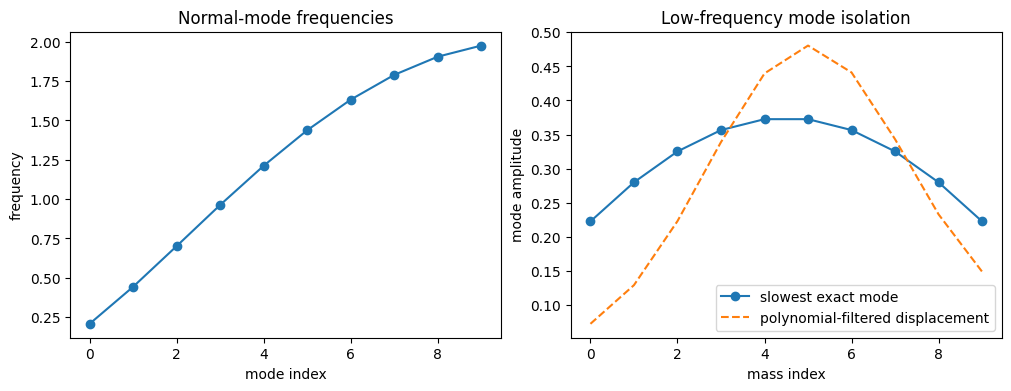

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

axes[0].plot(np.arange(n_masses), frequencies, "o-")
axes[0].set_xlabel("mode index")
axes[0].set_ylabel("frequency")
axes[0].set_title("Normal-mode frequencies")

axes[1].plot(np.arange(n_masses), slow_mode, "o-", label="slowest exact mode")
axes[1].plot(
    np.arange(n_masses), filtered, "--", label="polynomial-filtered displacement"
)
axes[1].set_xlabel("mass index")
axes[1].set_ylabel("mode amplitude")
axes[1].set_title("Low-frequency mode isolation")
axes[1].legend()

plt.show()

## Validation

Compact checks for positive stiffness and low-frequency mode filtering.


In [5]:
assert stiffness_eigenvalues[0] > 0.0
assert np.all(np.diff(frequencies) > 0.0)
assert slow_mode_overlap > 0.75

print("frequencies:", np.array2string(frequencies[:5], precision=4))
print(f"lowest_stiffness: {stiffness_eigenvalues[0]:.4e}")
print(f"slow_mode_overlap: {slow_mode_overlap:.4f}")
print("validation: passed")

frequencies: [0.2072 0.4426 0.7012 0.9629 1.2121]
lowest_stiffness: 4.2916e-02
slow_mode_overlap: 0.9147
validation: passed
